# Silhouette coefficients and Silhouette scores

scikit-learn and back-of-envelop calculatiions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, cluster

## Four points only

In [2]:
X = [[-1, -1],
     [-1,  1],
     [ 1, -1],
     [ 1,  1]]
y = [0, 1, 0, 1]
X = np.array(X); y = np.array(y)

print('Silhouette score calculated using scikit-learn')
print('before averaging:', end='')
print(metrics.silhouette_samples(X, y))
print('after averaging:', end='')
print(metrics.silhouette_score(X, y))

print('\nSilhouette score calculated manually back-of-the-envelop')
# a: mean intra-cluster distance
# b: mean inter-cluster distance
# s: Silhouette coefficient = (b-a) / max(a, b)
s = []
for ni in range(len(y)):
    a, b, na, nb = 0, 0, 0, 0
    for nj in range(len(y)):
        if y[ni]==y[nj]:
            a += np.linalg.norm(X[ni, :]-X[nj, :])
            na += 1
        else:
            b += np.linalg.norm(X[ni, :]-X[nj, :])
            nb += 1
    a /= na - 1
    b /= nb
    s.append( (b-a) / max(a, b) )
print('before averaging:', end='')
print(s)
print('after averaging:', end='')
print(np.mean(s))

Silhouette score calculated using scikit-learn
before averaging:[0.17157288 0.17157288 0.17157288 0.17157288]
after averaging:0.17157287525380985

Silhouette score calculated manually back-of-the-envelop
before averaging:[0.17157287525380985, 0.17157287525380985, 0.17157287525380985, 0.17157287525380985]
after averaging:0.17157287525380985


## Two concentric circles

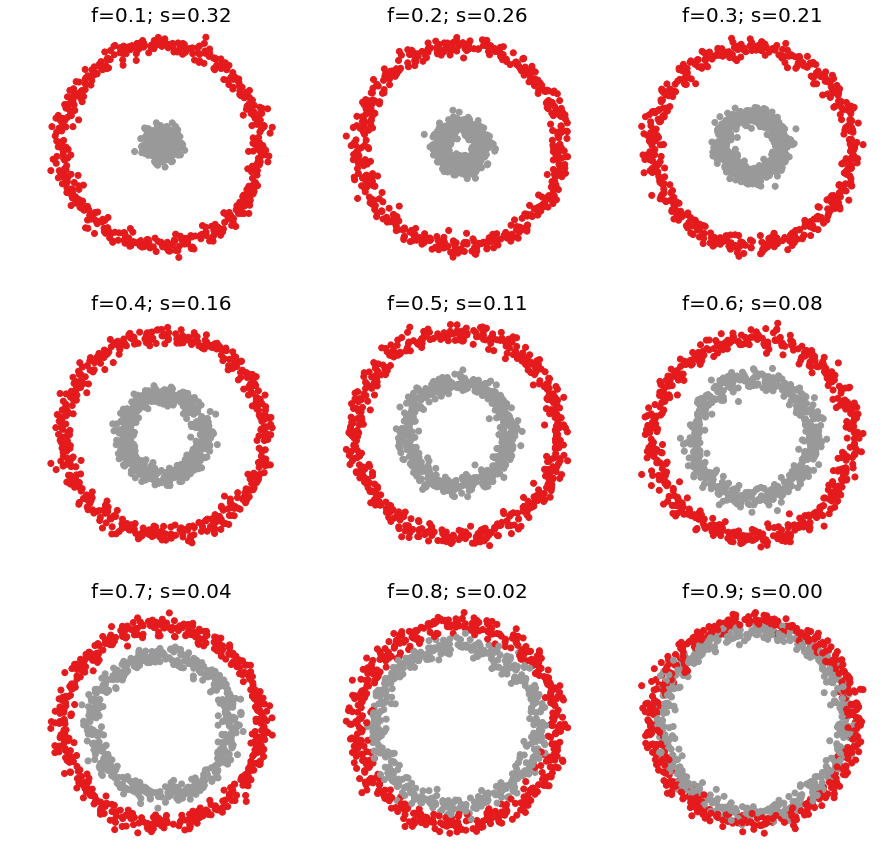

In [3]:
np.random.seed(77)
n_samples = 1000
plt.figure(figsize=(15, 15)); plt.set_cmap('Set1')
for n, factor in enumerate(np.arange(.1, 1, .1)):
    X, y = datasets.make_circles(n_samples=n_samples, factor=factor, noise=.05)
    plt.subplot(3, 3, n+1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal'); plt.axis('off')
    plt.title('f={:3.1f}; s={:4.2f}'.format(factor, metrics.silhouette_score(X, y)), size=20)
# Silhouette score deteriorates (decrease) with decreasing differentiation between clusters, eventually beginning to overlap

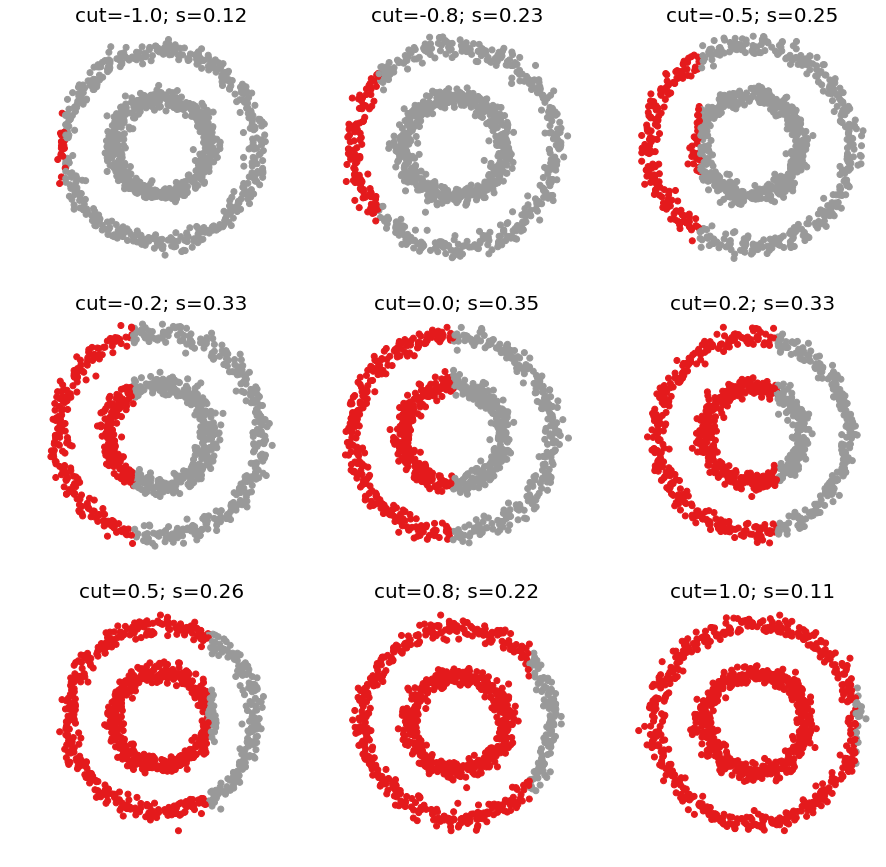

In [4]:
plt.figure(figsize=(15, 15)); plt.set_cmap('Set1')
for n, cut in enumerate(np.linspace(-1, 1, 9)):
    X, y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.05)
    y[np.where(X[:, 0]<cut)[0]] = 0
    y[np.where(X[:, 0]>=cut)[0]] = 1
    plt.subplot(3, 3, n+1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal'); plt.axis('off')
    plt.title('cut={:3.1f}; s={:4.2f}'.format(cut, metrics.silhouette_score(X, y)), size=20)

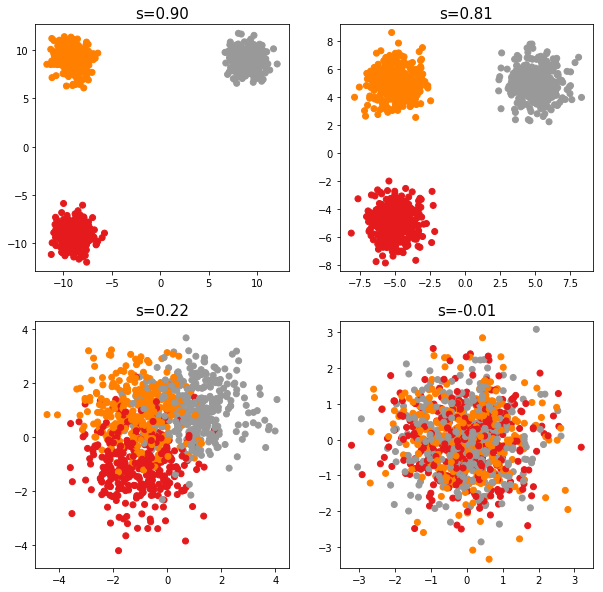

In [5]:
centerss = [[[-9, -9], [-9, 9], [9, 9]],
            [[-5, -5], [-5, 5], [5, 5]],
            [[-1, -1], [-1, 1], [1, 1]],
            [[ 0,  0], [ 0, 0], [0, 0]]]
plt.figure(figsize=(10, 10)); plt.set_cmap('Set1')
for n, centers in enumerate(centerss):         
    plt.subplot(2, 2, n+1)
    X, y = datasets.make_blobs(n_samples=n_samples, centers=centers)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal')
    plt.title('s={:4.2f}'.format(metrics.silhouette_score(X, y)), size=15)

Bibliography:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

https://en.wikipedia.org/wiki/Silhouette_(clustering)